In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
###Lets create a dataset for binary classification problem

from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=4)


In [3]:
X

array([[ 1.22515974, -0.95173116],
       [ 1.01630365, -1.72517506],
       [ 0.33534004, -1.7248955 ],
       ...,
       [ 1.54270795, -0.05566478],
       [ 0.81664566, -1.2509187 ],
       [ 1.13782254, -1.26151957]], shape=(1000, 2))

In [4]:
y

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,

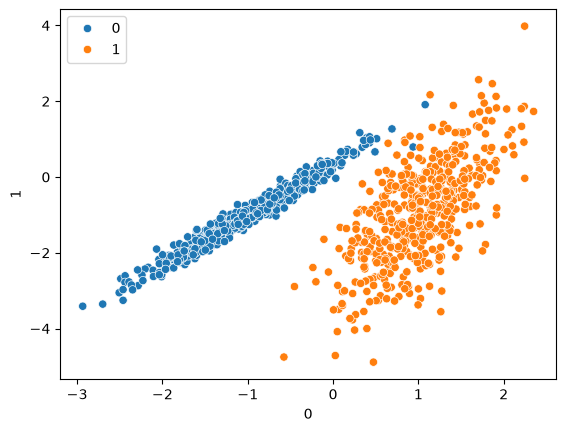

In [5]:
import pandas as pd 

X_df = pd.DataFrame(X)

sns.scatterplot(
    x=X_df[0],
    y=X_df[1],
    hue=y
)

plt.show()


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)



In [7]:
# We use linear kernal as our data is much seperate you can use the polynomial, rbf , sigmoide it depends on how your data is 

from sklearn.svm import SVC

svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

y_pred = svc.predict(X_test)







In [8]:
# We import some matrices so that we can check our model report like precison , recall , 

from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))




[[100   1]
 [  0  99]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       101
           1       0.99      1.00      0.99        99

    accuracy                           0.99       200
   macro avg       0.99      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200



In [9]:
# we import accuracy matrics so that we can check our model accuracy
from sklearn.metrics import accuracy_score

print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 0.995


In [10]:
### Train vs Test score: if train is much higher than test, the model is overfitting

train_acc = svc.score(X_train, y_train)
test_acc = svc.score(X_test, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy :", test_acc)
print("Gap (train - test):", train_acc - test_acc)

Train accuracy: 0.99625
Test accuracy : 0.995
Gap (train - test): 0.0012499999999999734


In [11]:
### Cross-validation: more reliable than a single train/test split

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(SVC(kernel='linear'), X, y, cv=5, scoring='accuracy')

print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std deviation   :", cv_scores.std())

CV scores: [1.    0.995 0.99  0.995 1.   ]
Mean CV accuracy: 0.9960000000000001
Std deviation   : 0.0037416573867739447


ROC-AUC: 0.9997999799979997


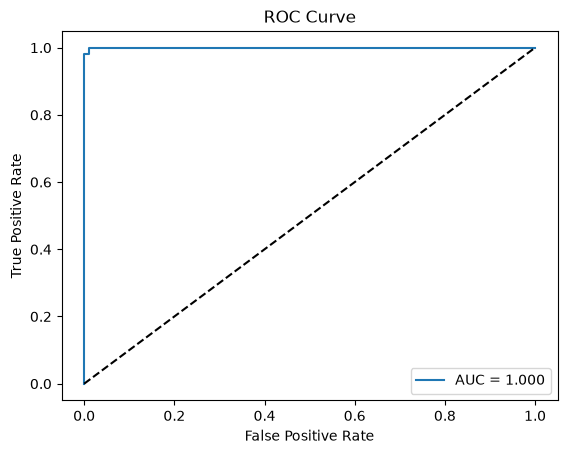

In [12]:
### ROC-AUC: how well the model ranks class 1 vs class 0 (1.0 is perfect, 0.5 is random)

from sklearn.metrics import roc_auc_score, roc_curve

# probability=True is needed for predict_proba; decision_function also works for SVM
y_scores = svc.decision_function(X_test)
auc = roc_auc_score(y_test, y_scores)
print("ROC-AUC:", auc)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

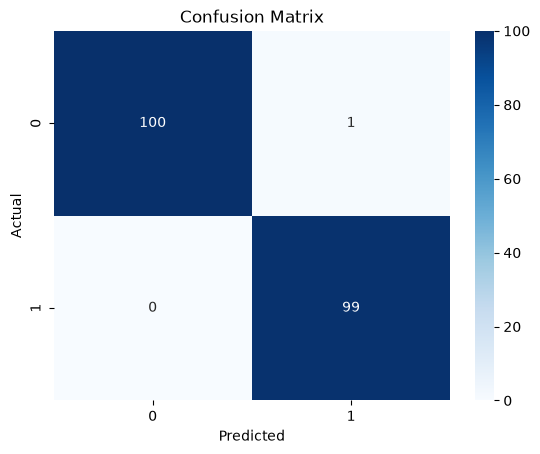

In [13]:
### Heatmap of confusion matrix (easy visual check)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Lets perform hyperparameter tunning for best accuracy

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# 1. Define the hyperparameter grid you want to search over
param_grid = {
    'C': [0.1, 1, 10, 100],  
    'gamma': [1, 0.1, 0.01, 0.001], 
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

# 2. Initialize the GridSearchCV object
# refit=True means it will automatically fit the model on the whole training set using the best parameters found
# verbose=3 will print out the progress of the training
# cv=5 means it will use 5-fold cross-validation
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3, cv=5)

# 3. Fit the grid search to your training data
grid.fit(X_train, y_train)

# 4. Print out the best parameters that the grid search found
print("Best Parameters found by GridSearchCV:")
print(grid.best_params_)
print("\nBest Estimator:")
print(grid.best_estimator_)

# 5. Make predictions on the test set using the best model
grid_predictions = grid.predict(X_test)

# 6. Evaluate the tuned model
from sklearn.metrics import classification_report, confusion_matrix
print("\nConfusion Matrix for Best Model:")
print(confusion_matrix(y_test, grid_predictions))
print("\nClassification Report for Best Model:")
print(classification_report(y_test, grid_predictions))


Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=1.000 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.981 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=1.000 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.994 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=1.000 total time=   0.0s
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.994 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.981 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.975 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly

## SVM Kernals Implementation

In [15]:
import numpy as np
import matplotlib.pyplot as plt
# 1. Create the Outer Arcs (Class 0)
x = np.linspace(-5.0, 5.0, 100)
y = np.sqrt(10**2 - x**2)
y = np.hstack([y, -y])
x = np.hstack([x, -x]) # Note: taking -x ensures the pairs match up correctly

In [16]:
# 2. Create the Inner Circle (Class 1)
x1 = np.linspace(-5.0, 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)
y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1])

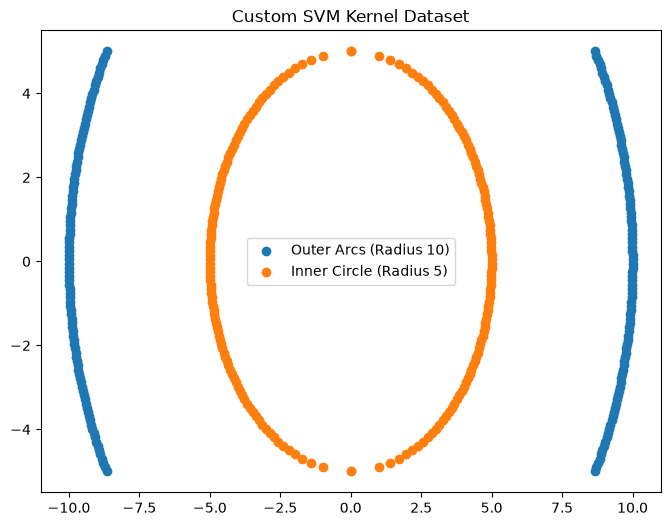

In [17]:
# 3. Plot them (Swapping the axes with plt.scatter(y, x))
plt.figure(figsize=(8, 6))
plt.scatter(y, x, label="Outer Arcs (Radius 10)")
plt.scatter(y1, x1, label="Inner Circle (Radius 5)")
plt.legend()
plt.title("Custom SVM Kernel Dataset")
plt.show()

In [18]:
import pandas as pd

# Create DataFrame for Outer Arcs (Class 0)
df1 = pd.DataFrame(np.vstack([y, x]).T, columns=['X1', 'X2'])
df1['Y'] = 0

# Create DataFrame for Inner Circle (Class 1)
df2 = pd.DataFrame(np.vstack([y1, x1]).T, columns=['X1', 'X2'])
df2['Y'] = 1

# Use pd.concat instead of .append()
df = pd.concat([df1, df2], ignore_index=True)



In [19]:

df.head(5)

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [20]:

df.tail(5)

,X1,X2,Y
395,-1.969049,-4.59596,1
396,-1.714198,-4.69697,1
397,-1.406908,-4.79798,1
398,-0.999949,-4.89899,1
399,-0.000000,-5.00000,1


In [21]:
### Dependent and independent features 
X = df.iloc[:, :2]
y = df.Y

In [22]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [23]:
## split the dataset into the train and test 

from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.25 ,  random_state=0)

In [24]:
y_train

250    1
63     0
312    1
159    0
283    1
      ..
323    1
192    0
117    0
47     0
172    0
Name: Y, Length: 300, dtype: int64

## Plynomial kernal  

When we use Polynomial 
In Polynomial kernals we just squares all the features and then multiply the features 

In [ ]:
# We need to find components for the Polynomial Kernel
#[X1,X2,X1_square,X2_square,X1*X2] important 
df['X1_Square'] = df['X1']**2
df['X2_Square'] = df['X2']**2
df['X1*X2'] = (df['X1'] * df['X2'])
df.head()

,X1,X2,Y,X1_Square,X2_Square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [26]:
### Update dependent and independent features

# Pass the list of columns to df to get the actual data
X = df[['X1', 'X2', 'X1_Square', 'X2_Square', 'X1*X2']]
y = df['Y']


In [27]:
## Again train test split 

X_train, X_test ,y_train, y_test = train_test_split(X,y, test_size=0.25 , random_state=0)

In [28]:
X_train

,X1,X2,X1_Square,X2_Square,X1*X2
250,4.999745,0.050505,24.997449,0.002551,0.252512
63,9.906589,1.363636,98.140496,1.859504,13.508984
312,-3.263736,3.787879,10.651974,14.348026,-12.362637
159,-9.953852,-0.959596,99.079176,0.920824,9.551676
283,3.680983,3.383838,13.549638,11.450362,12.455852
...,...,...,...,...,...
323,-4.223140,2.676768,17.834915,7.165085,-11.304366
192,-9.031653,-4.292929,81.570758,18.429242,38.772248
117,-9.445795,3.282828,89.223038,10.776962,-31.008922
47,9.996811,-0.252525,99.936231,0.063769,-2.524447


In [29]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    1
399    1
Name: Y, Length: 400, dtype: int64

In [30]:
import plotly.express as px

fig = px.scatter_3d(df, x='X1', y='X2', z='X1*X2',
                    color='Y')

fig.show()

In [ ]:
fig = px.scatter_3d(df, x='X1_Square', y='X1_Square', z='X1*X2',
                    color='Y')

fig.show()

In [32]:
## now we can create a hyperplane 

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

accuracy_score(y_test, y_pred)

1.0

In [ ]:
"""Acuuracy 1.0 aai hai which is nice in this polynomial kernal we see how to polynomial kernal
internally works even we dont need to do manual steps we can just use
kernal = poly then it do everything automatically"""

# example = ## now we can create a hyperplane 

# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score

# classifier = SVC(kernel="poly")
# classifier.fit(X_train, y_train)

# y_pred = classifier.predict(X_test)

# accuracy_score(y_test, y_pred)


"""Note - but when we do manually all the operations like squaring all the independent column and multiply each
then we canuse kernal = linear becouse now data is seperated na """

#### RDF = Radial Basis Function Kernal

In [34]:
 ## now we can use rbs also 

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

classifier = SVC(kernel="rbf")
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

accuracy_score(y_test, y_pred)

1.0

In [35]:
## now we can use sigoid also 

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

classifier = SVC(kernel="sigmoid")
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

accuracy_score(y_test, y_pred)

1.0